**Importing libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset loading**

In [2]:
df = pd.read_csv("customer_behavior.csv")

In [3]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
df.shape

(350, 11)

In [5]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [7]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


**Checking and handling missing values**

In [8]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


In [9]:
df['Satisfaction Level'].fillna(df['Satisfaction Level'].mode()[0], inplace=True)

/tmp/ipykernel_258/3607365204.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Satisfaction Level'].fillna(df['Satisfaction Level'].mode()[0], inplace=True)


In [10]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


In [11]:
df['Gender'] = df['Gender'].astype('category')
df['City'] = df['City'].astype('category')
df['Membership Type'] = df['Membership Type'].astype('category')
df['Satisfaction Level'] = df['Satisfaction Level'].astype('category')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Customer ID               350 non-null    int64   
 1   Gender                    350 non-null    category
 2   Age                       350 non-null    int64   
 3   City                      350 non-null    category
 4   Membership Type           350 non-null    category
 5   Total Spend               350 non-null    float64 
 6   Items Purchased           350 non-null    int64   
 7   Average Rating            350 non-null    float64 
 8   Discount Applied          350 non-null    bool    
 9   Days Since Last Purchase  350 non-null    int64   
 10  Satisfaction Level        350 non-null    category
dtypes: bool(1), category(4), float64(2), int64(4)
memory usage: 18.8 KB


**EDA**

*Age distribution*

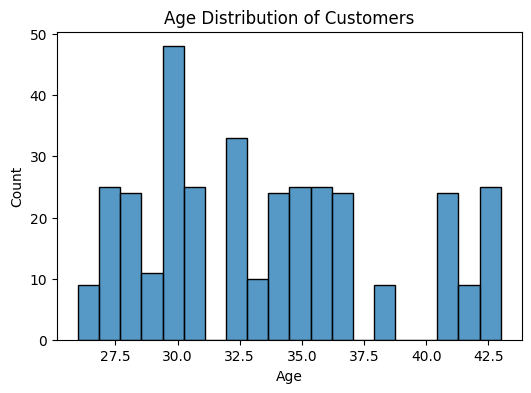

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution of Customers")
plt.show()

*Gender distribution*

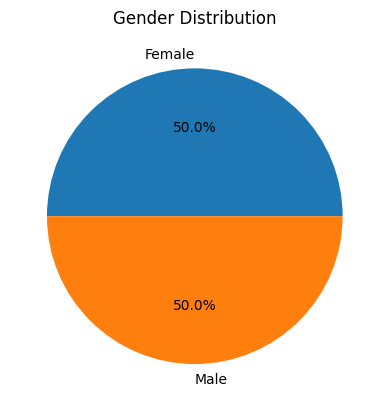

In [14]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

*Membership Type Distribution*

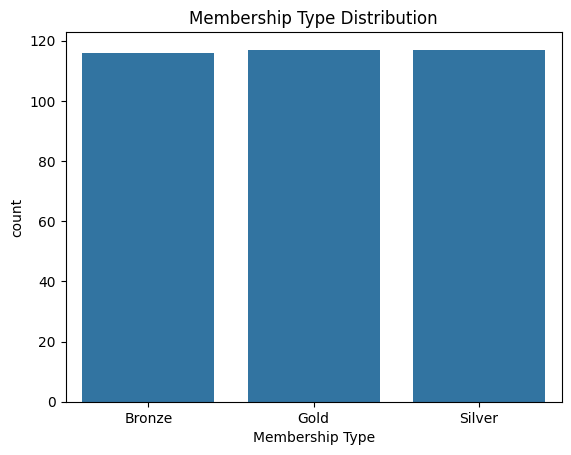

In [15]:
sns.countplot(x='Membership Type', data=df)
plt.title("Membership Type Distribution")
plt.show()

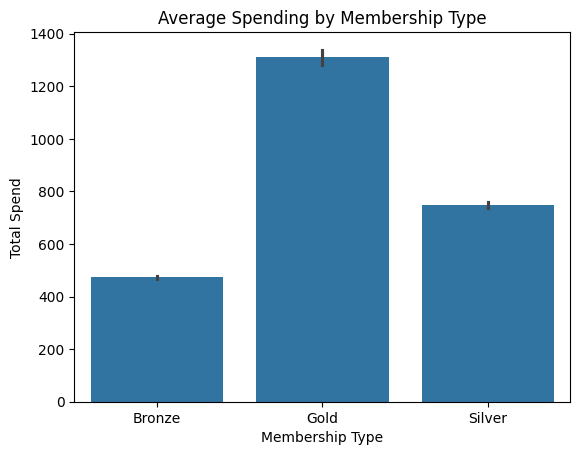

In [16]:
sns.barplot(x='Membership Type', y='Total Spend', data=df)
plt.title("Average Spending by Membership Type")
plt.show()

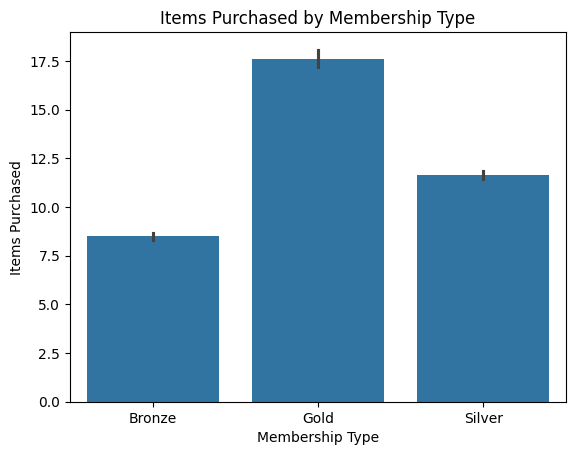

In [17]:
sns.barplot(x='Membership Type', y='Items Purchased', data=df)
plt.title("Items Purchased by Membership Type")
plt.show()

*Impact of discount*

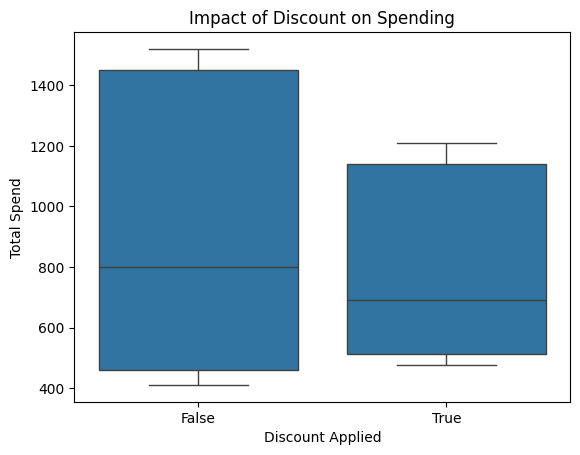

In [18]:
sns.boxplot(x='Discount Applied', y='Total Spend', data=df)
plt.title("Impact of Discount on Spending")
plt.show()

*Satisfaction Level Analysis*

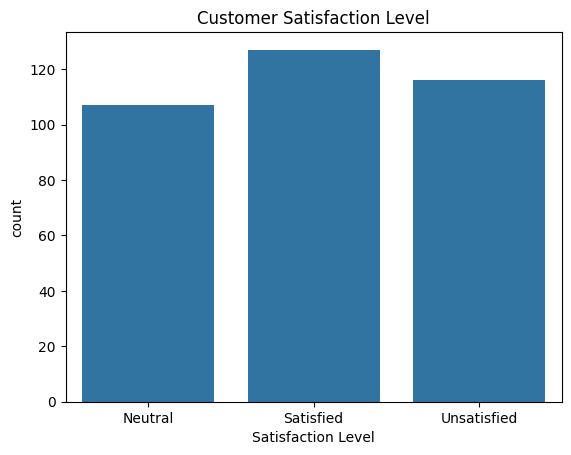

In [19]:
sns.countplot(x='Satisfaction Level', data=df)
plt.title("Customer Satisfaction Level")
plt.show()

**Retention analysis**

In [20]:
def customer_status(days):
    if days <= 30:
        return "Active"
    elif days <= 60:
        return "At Risk"
    else:
        return "Churn Risk"

df['Customer Status'] = df['Days Since Last Purchase'].apply(customer_status)

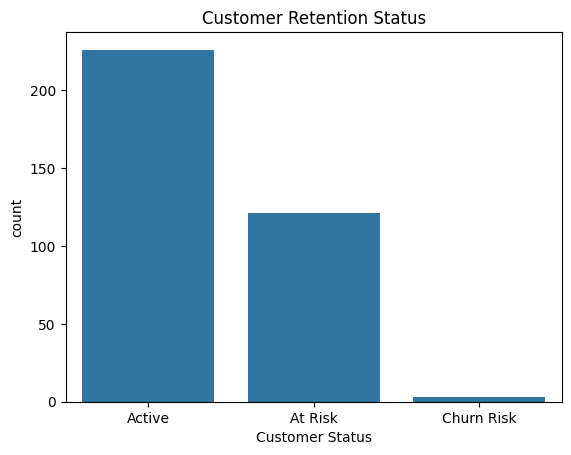

In [21]:
sns.countplot(x='Customer Status', data=df)
plt.title("Customer Retention Status")
plt.show()

**Heatmap**

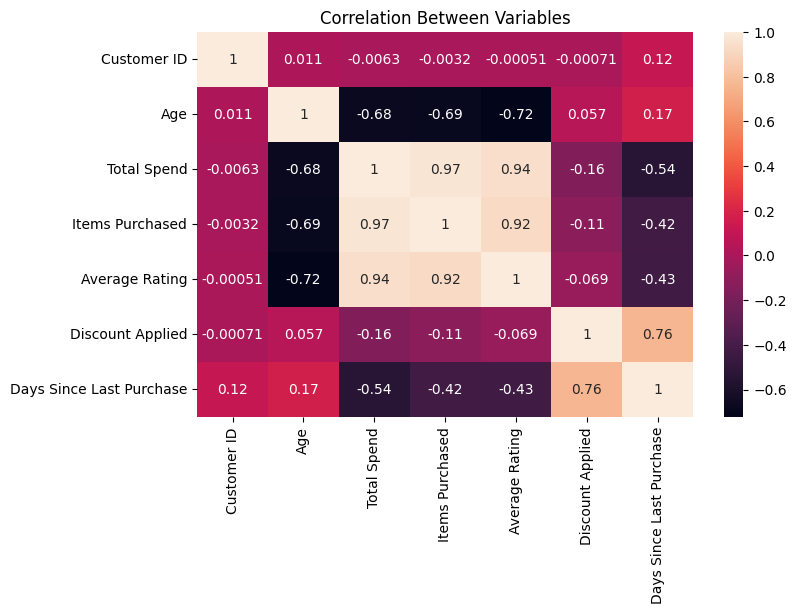

In [22]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Variables")
plt.show()

**Key findings**



*   Gold members generate higher total spending compared to other membership types.
*   Discounts appear to positively influence customer purchasing behavior.

*   Most customers show good satisfaction levels based on ratings.
*   Some customers fall into the at-risk category based on days since their last purchase.





**Actionable Insights**


*   Provide loyalty rewards to high-value customers.
*   Use targeted promotions to re-engage inactive customers.

*   Continue discount campaigns to encourage purchases.*italicized text*



